#   LangGraph 활용 - Adaptive RAG (Part1)

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import warnings
warnings.filterwarnings("ignore")

`(3) langfuase handler 설정`

In [3]:
from langfuse.langchain import CallbackHandler

# 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

---

## **Adaptive RAG**

- Adaptive RAG는 (1) 쿼리 분석과 (2) 능동적/자기 수정적 RAG를 결합한 전략

- 질문의 특성에 따라 가장 적합한 검색 및 응답 방식을 선택

- 논문에서의 라우팅 전략:
    1. No Retrieval: 검색 없이 직접 응답 
    1. Single-shot RAG: 단일 검색 후 응답 
    1. Iterative RAG: 반복적인 검색과 응답 과정 

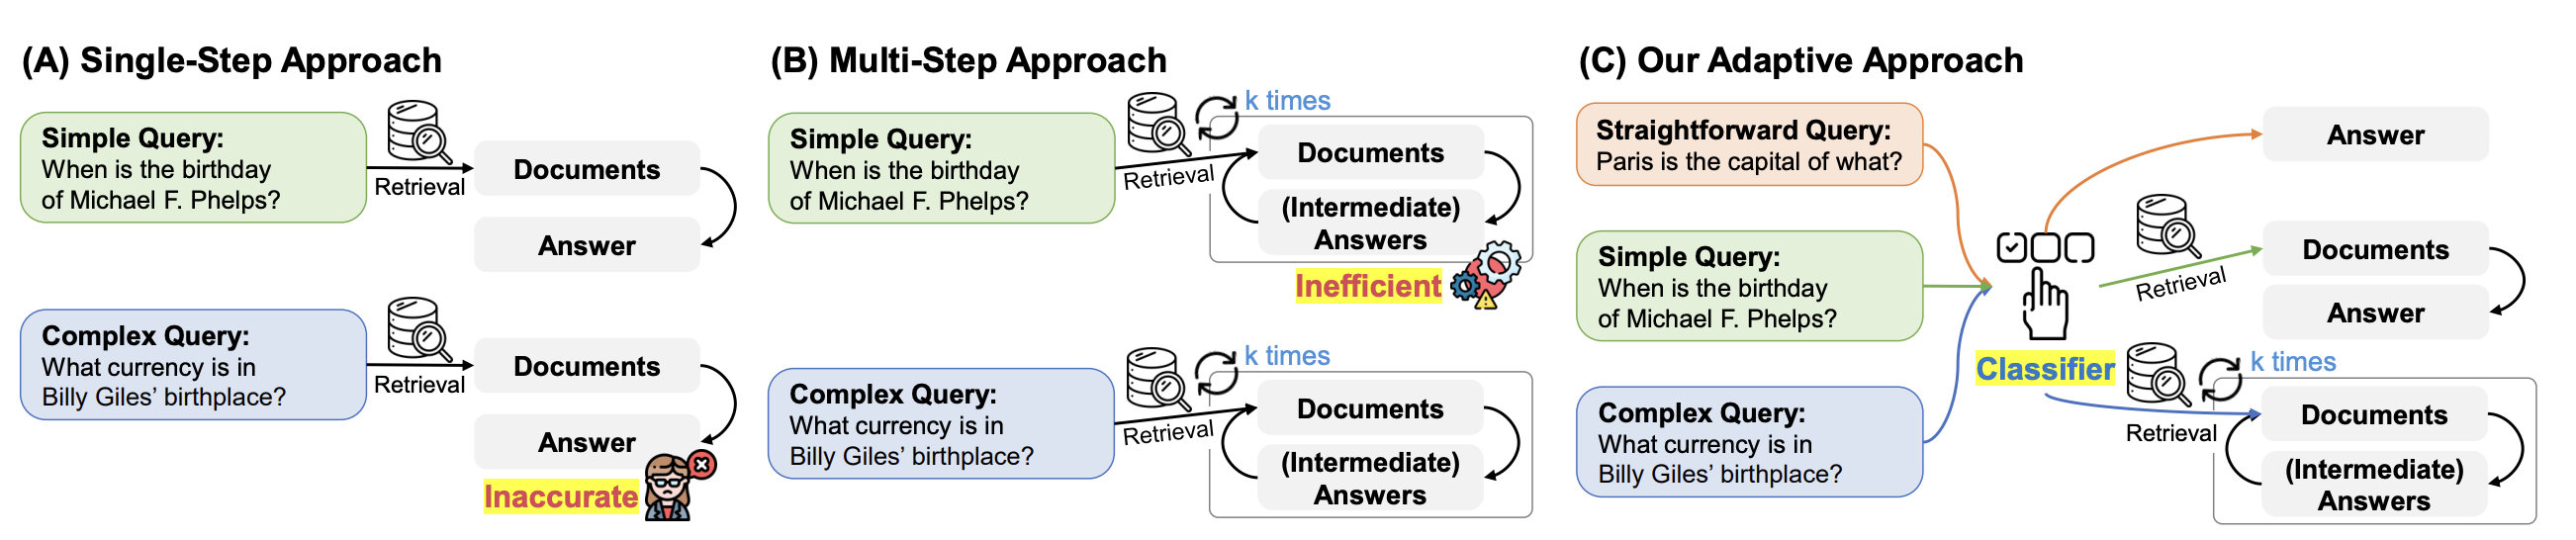

- 논문: https://arxiv.org/abs/2403.14403


---

## **기본 개념(Conceptual Example)** 구현

- LangGraph의 StateGraph에서 **3가지 라우팅 전략**을 구현: No Retrieval, Single-shot RAG, Iterative RAG

- 각 전략은 **쿼리 분석 결과**에 기반하여 자동으로 선택되며 실행 중 전환이 가능

- 시스템은 **자기 수정적 특성**을 가져 응답 품질을 지속적으로 모니터링하고 개선

    - **`Start`**: 프로세스 시작

    - **`AnalyzeQuery`**: 쿼리 분석 및 라우팅 전략 결정

    - **`NoRetrieval`**: 검색 없이 직접 응답 생성

    - **`SingleShotRAG`**: 단일 검색 후 응답 생성

    - **`IterativeRAG`**: 반복 검색 및 응답 생성 

    - **`GenerateResponse`**: 최종 응답 생성 및 출력
    
    - **`End`**: 프로세스 종료

### **1. AnalyzeQuery**

- 입력된 질문을 분석하여 **최적의 RAG 전략**을 선택

- 질문의 **복잡성**, **도메인**, **필요 지식 수준**을 평가

- 분석 결과에 따라 적절한 **라우팅 결정**을 수행

In [4]:
from typing import Literal
from pydantic import BaseModel
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

class QueryRoute(BaseModel):
    strategy: Literal["no_retrieval", "single_lookup", "iterative"]
    reason: str

def route_query(query: str) -> QueryRoute:
    router_prompt = ChatPromptTemplate.from_messages([
        ("system", """
        당신은 레스토랑 서비스 담당자입니다. 
        레스토랑에서 제공하는 메뉴와 와인에 대한 DB를 각각 보유하고 있습니다. 
        
        주어진 질문을 분석하여 다음 전략 중 하나를 선택하세요:
        1. no_retrieval: 일반 상식, 간단한 계산 등 검색 불필요
        2. single_lookup: 단순 사실 확인, 정의 등 1회 검색
        3. iterative: 페어링, 비교, 복잡한 분석, 다단계 추론 필요한 경우
        """),
        ("user", "{query}")
    ])

    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
    chain = router_prompt | llm.with_structured_output(QueryRoute)
    routing = chain.invoke(query)
    
    return routing

# 쿼리 라우팅 테스트
test_queries = [
    "파스타 메뉴가 있나요?",
    "스테이크와 어울리는 와인을 추천해주세요.",
    "프랑스의 수도는 어디인가요?",
]

for query in test_queries:
    routing = route_query(query)
    print(f"쿼리: {query}")
    print(f"라우팅: {routing}")
    print("-" * 100)

쿼리: 파스타 메뉴가 있나요?
라우팅: strategy='single_lookup' reason='파스타 메뉴의 유무를 확인하는 단순 사실 확인 질문이므로, 메뉴 DB에서 한번 검색하면 충분하다.'
----------------------------------------------------------------------------------------------------
쿼리: 스테이크와 어울리는 와인을 추천해주세요.
라우팅: strategy='single_lookup' reason='스테이크와 잘 어울리는 와인 종류를 데이터베이스에서 한 번 조회하여 추천할 수 있기 때문입니다.'
----------------------------------------------------------------------------------------------------
쿼리: 프랑스의 수도는 어디인가요?
라우팅: strategy='no_retrieval' reason='프랑스의 수도는 일반 상식에 해당하는 정보로, 별도의 데이터 검색 없이 답변할 수 있습니다.'
----------------------------------------------------------------------------------------------------


#### **[실습]**  입력 질문을 분석하고 라우팅하는 체인을 개선하여 구현합니다. 

In [ ]:
# 여기에 코드를 작성하세요.

# [실습] 개선된 쿼리 라우팅 체인 구현

from typing import Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

class QueryRoute(BaseModel):
    strategy: Literal["no_retrieval", "single_lookup", "iterative"]
    reason: str
    confidence: float = Field(..., description="라우팅 결정의 신뢰도 (0-1)")
    suggested_databases: list[str] = Field(default_factory=list, description="검색할 데이터베이스 목록")

def improved_route_query(query: str) -> QueryRoute:
    """개선된 쿼리 분석 및 라우팅 함수"""
    
    router_prompt = ChatPromptTemplate.from_messages([
        ("system", """
        당신은 레스토랑 서비스 전문가입니다. 
        두 개의 데이터베이스를 보유하고 있습니다:
        1. menu_db: 레스토랑 메뉴 정보 (음식, 가격, 재료, 조리법 등)
        2. wine_db: 와인 정보 (종류, 특성, 페어링 추천 등)
        
        질문을 분석하여 최적의 전략과 데이터베이스를 선택하세요:
        
        [전략 선택 기준]
        1. no_retrieval: 
           - 일반 상식, 간단한 인사, 레스토랑과 무관한 질문
           - 예: "안녕하세요", "프랑스의 수도는?", "1+1은?"
           
        2. single_lookup: 
           - 단일 정보 검색으로 답변 가능
           - 단순 메뉴 확인, 가격 문의, 특정 와인 정보
           - 예: "파스타 있나요?", "샤르도네 와인 있나요?"
           
        3. iterative: 
           - 복잡한 추론과 다중 검색 필요
           - 음식-와인 페어링, 비교 분석, 추천
           - 예: "스테이크와 어울리는 와인 추천", "채식 메뉴와 와인 조합"
        
        [데이터베이스 선택]
        - menu_db: 메뉴, 음식, 요리 관련 질문
        - wine_db: 와인, 음료 관련 질문
        - 둘 다: 페어링, 조합, 추천 질문
        """),
        ("user", "{query}")
    ])

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    chain = router_prompt | llm.with_structured_output(QueryRoute)
    routing = chain.invoke({"query": query})
    
    return routing

# 개선된 라우팅 테스트
test_queries = [
    "파스타 메뉴가 있나요?",
    "스테이크와 어울리는 와인을 추천해주세요.",
    "프랑스의 수도는 어디인가요?",
    "채식주의자를 위한 메뉴와 와인 페어링을 추천해주세요.",
    "가장 비싼 메뉴는 무엇인가요?",
]

print("=" * 100)
print("개선된 쿼리 라우팅 테스트")
print("=" * 100)

for query in test_queries:
    routing = improved_route_query(query)
    print(f"\n쿼리: {query}")
    print(f"전략: {routing.strategy}")
    print(f"신뢰도: {routing.confidence:.2f}")
    print(f"데이터베이스: {routing.suggested_databases}")
    print(f"이유: {routing.reason}")
    print("-" * 100)

### **2. NoRetrieval**

- 외부 검색 없이 **LLM의 기본 지식**으로 응답

- 일반적 지식이나 **상식적 질문**에 적합한 전략

- 간단하고 일반적인 질문에 대한 **효율적인 응답 전략**


In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 검색 결과를 사용하지 않고 질문에 대답하는 함수
def no_retrieval_response(query: str) -> str:
    """외부 지식 없이 질문에 직접 답변하는 함수"""

    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)

    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 도움이 되는 인공지능 어시스턴트입니다. 외부 지식을 사용하지 않고 직접 질문에 답변하세요."), 
        ("user", "{query}"),
    ])

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({"query": query})

    return response

# 테스트 실행
response = no_retrieval_response("스테이크와 어울리는 와인을 추천해주세요.")
pprint(response)

('스테이크와 어울리는 와인은 일반적으로 풍부한 바디와 탄닌이 있는 레드 와인이 잘 어울립니다. 대표적으로는 다음과 같은 와인들이 '
 '있습니다:\n'
 '\n'
 '1. 카베르네 소비뇽 (Cabernet Sauvignon) – 강한 탄닌과 진한 과일 맛이 스테이크의 풍미를 잘 살려줍니다.\n'
 '2. 멜롯 (Merlot) – 부드럽고 과일향이 풍부해 부담 없이 즐길 수 있습니다.\n'
 '3. 쉬라즈/시라 (Shiraz/Syrah) – 스파이시하고 진한 맛이 스테이크와 잘 어울립니다.\n'
 '4. 말벡 (Malbec) – 진한 다크 베리 향과 부드러운 탄닌으로 고기 요리와 좋은 조합입니다.\n'
 '\n'
 '스테이크의 조리 방법과 양념에 따라 와인 선택이 달라질 수 있으니 참고해 주세요!')


#### **[실습]**  단순 질의응답을 수행하는 체인을 개선하여 구현합니다. 

In [ ]:
# 여기에 코드를 작성하세요.

# [실습] 개선된 NoRetrieval 체인 구현

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from textwrap import dedent

def improved_no_retrieval_response(query: str) -> dict:
    """개선된 외부 지식 없이 질문에 직접 답변하는 함수"""

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

    prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
            당신은 친절한 레스토랑 서비스 전문가입니다. 
            
            [역할]
            - 고객의 일반적인 질문에 친절하고 전문적으로 답변합니다
            - 레스토랑 맥락에서 벗어난 질문도 정중하게 응대합니다
            - 필요시 레스토랑 정보로 자연스럽게 유도합니다
            
            [가이드라인]
            1. 간결하고 명확하게 답변하세요
            2. 전문적이면서도 친근한 톤을 유지하세요
            3. 레스토랑과 무관한 질문에도 정중하게 응답하세요
            4. 필요시 "메뉴나 와인에 대해 더 궁금하신 점이 있으시면 말씀해주세요"와 같은 안내를 추가하세요
        """)),
        ("user", "{query}"),
    ])

    chain = prompt | llm | StrOutputParser()
    response = chain.invoke({"query": query})

    return {
        "answer": response,
        "strategy": "no_retrieval",
        "source": "LLM 내장 지식"
    }

# 테스트 실행
print("=" * 100)
print("개선된 NoRetrieval 테스트")
print("=" * 100)

test_queries = [
    "안녕하세요!",
    "프랑스의 수도는 어디인가요?",
    "와인과 맥주의 차이는 무엇인가요?",
    "스테이크는 어떻게 먹는 게 좋나요?",
]

for query in test_queries:
    print(f"\n질문: {query}")
    result = improved_no_retrieval_response(query)
    print(f"답변: {result['answer']}")
    print(f"전략: {result['strategy']}")
    print("-" * 100)

### **3. SingleShotRAG**

- 쿼리당 **한 번의 검색**만 수행하는 **빠르고 효율적인 기본 RAG 전략**

- 검색된 문서는 **컨텍스트로 통합**되어 단일 응답을 생성

- 간단하고 명확한 질문에 **효율적**이며 시스템 리소스를 절약 가능

- **실행 속도가 빠르나** 복잡한 쿼리의 정확도는 제한적일 수 있음 

`(1) 벡터저장소 검색 (Retrieval)`

In [8]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma 인덱스 로드 
menu_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="restaurant_menu",
    persist_directory="./chroma_db",
)

wine_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="restaurant_wine",
    persist_directory="./chroma_db",
)

# 검색도구 생성 
munu_retriever= menu_db.as_retriever(search_kwargs={"k":3})
wine_retriever= wine_db.as_retriever(search_kwargs={"k":3})

# 검색 테스트
query = "스테이크와 어울리는 와인을 추천해주세요."
menu_results = munu_retriever.invoke(query)

pprint(menu_results)

[]


`(2) 검색 문서 포맷팅 (Augmentation)`

In [9]:
from langchain_core.documents import Document

# 문서 출처를 함께 표시하는 포맷 변환 함수
def format_docs(docs: list[Document]) -> str:
    formatted_result = ""
    for doc in docs:
        formatted_result += f"{doc.page_content}\n(출처: {doc.metadata['source']} - [{doc.metadata['menu_number']}]{doc.metadata['menu_name']})"
        formatted_result += "\n-----------------------------------------------\n"

    return formatted_result

# 검색 결과를 사용하여 테스트
print(format_docs(menu_results))

`(3) 질문 답변 체인 (Generation)`

In [10]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate 
from langchain_core.vectorstores import VectorStore
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from textwrap import dedent
from operator import itemgetter

def create_rag_chain(vectorstore: VectorStore, k: int = 3) -> RunnableParallel:
    # RAG 체인 구성
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": k}
    )
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
    
    # RAG 프롬프트 템플릿
    prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
                주어진 컨텍스트를 사용하여 질문에 답변하세요. 
                
                [가이드라인]
                1. 컨텍스트에 정보가 없거나 부족하면 '근거가 없습니다'라고 답변하세요.
                2. 답변을 할 때는 참조한 출처 또는 근거를 표시합니다. (출처: 파일경로 또는 URL - [메뉴번호]메뉴이름)
                """)
        ),
        ("user", "[컨텍스트]\n{context}\n\n[질문]\n{question}\n\n[답변]\n"),
    ])
    
    # RAG 체인 정의
    chain = (
        RunnableParallel({
            "context": retriever | format_docs, 
            "question": RunnablePassthrough(),
            "docs": retriever
        })
        | RunnableParallel({
            "answer": prompt | llm | StrOutputParser(),
            "docs": itemgetter("docs")
        })
    )
    
    return chain

# Single-shot RAG 함수
def single_rag_response(query: str, vectorstore: VectorStore) -> str:
    """단일 질문에 대한 RAG 기반 답변을 생성하는 함수"""

    # RAG 체인 생성
    chain = create_rag_chain(vectorstore)

    # RAG 체인 실행
    response = chain.invoke(query)

    return response

# 테스트 실행
response = single_rag_response("스테이크와 어울리는 와인을 추천해주세요.", menu_db)
pprint(response)
print("-" * 100)
response = single_rag_response("스테이크와 어울리는 와인을 추천해주세요.", wine_db)
pprint(response)

{'answer': '근거가 없습니다.', 'docs': []}
----------------------------------------------------------------------------------------------------
{'answer': '근거가 없습니다.', 'docs': []}


#### **[실습]**  SingleShotRAG 체인을 개선하여 구현합니다. 

In [ ]:
# 여기에 코드를 작성하세요.

# [실습] 개선된 SingleShotRAG 체인 구현

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate 
from langchain_core.vectorstores import VectorStore
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.documents import Document
from textwrap import dedent
from operator import itemgetter
from typing import List

def improved_format_docs(docs: List[Document]) -> str:
    """개선된 문서 포맷팅 함수"""
    if not docs:
        return "검색된 정보가 없습니다."
    
    formatted_result = ""
    for i, doc in enumerate(docs, 1):
        formatted_result += f"[문서 {i}]\n"
        formatted_result += f"{doc.page_content}\n"
        
        # 메타데이터가 있는 경우에만 출처 표시
        if doc.metadata:
            source = doc.metadata.get('source', '알 수 없음')
            menu_name = doc.metadata.get('menu_name', '')
            menu_number = doc.metadata.get('menu_number', '')
            
            if menu_name and menu_number:
                formatted_result += f"(출처: {source} - [{menu_number}] {menu_name})\n"
            elif source != '알 수 없음':
                formatted_result += f"(출처: {source})\n"
        
        formatted_result += "-" * 80 + "\n"
    
    return formatted_result

def improved_single_rag_response(query: str, databases: dict, k: int = 5) -> dict:
    """개선된 단일 RAG 응답 생성 함수 - 다중 데이터베이스 지원"""
    
    # 다중 데이터베이스에서 검색
    all_docs = []
    for db_name, vectorstore in databases.items():
        retriever = vectorstore.as_retriever(search_kwargs={"k": k})
        docs = retriever.invoke(query)
        # 데이터베이스 출처 정보 추가
        for doc in docs:
            doc.metadata['database'] = db_name
        all_docs.extend(docs)
    
    # 관련성 기준으로 정렬 (검색 스코어가 있다면)
    # 여기서는 상위 k개만 선택
    all_docs = all_docs[:k]
    
    # RAG 프롬프트 구성
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
            당신은 레스토랑 서비스 전문가입니다.
            주어진 컨텍스트를 활용하여 고객의 질문에 답변하세요.
            
            [가이드라인]
            1. 컨텍스트에 정보가 있으면 이를 기반으로 구체적으로 답변하세요
            2. 컨텍스트에 정보가 부족하거나 없으면 "죄송하지만 해당 정보를 찾을 수 없습니다"라고 답변하세요
            3. 답변할 때는 참조한 출처를 명시하세요
            4. 여러 옵션이 있다면 고객이 선택할 수 있도록 나열하세요
            5. 친절하고 전문적인 톤을 유지하세요
        """)),
        ("user", "[컨텍스트]\n{context}\n\n[질문]\n{question}\n\n[답변]\n"),
    ])
    
    # 컨텍스트 생성
    context = improved_format_docs(all_docs)
    
    # 체인 실행
    chain = prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "question": query})
    
    return {
        "answer": answer,
        "docs": all_docs,
        "strategy": "single_shot_rag",
        "num_docs": len(all_docs)
    }

# 테스트 실행
print("=" * 100)
print("개선된 SingleShotRAG 테스트")
print("=" * 100)

# 테스트할 데이터베이스 구성
databases = {
    "menu_db": menu_db,
    "wine_db": wine_db
}

test_queries = [
    "파스타 메뉴가 있나요?",
    "레드 와인 추천해주세요",
    "스테이크와 어울리는 와인은 무엇인가요?",
]

for query in test_queries:
    print(f"\n질문: {query}")
    result = improved_single_rag_response(query, databases, k=3)
    print(f"답변: {result['answer']}")
    print(f"검색된 문서 수: {result['num_docs']}")
    print(f"전략: {result['strategy']}")
    print("-" * 100)

### **4. IterativeRAG**

- **`IterativeRAG`** 는 **단계적 검색**과 응답 생성을 반복하는 고급 전략

- 각 반복마다 **이전 결과를 분석**하여 추가 검색 방향을 결정

- 복잡하거나 **다단계 질문**에 적합하며 정확도가 높음

- **[예시]**: 쿼리 재작성 -> 문서 검색 -> 답변 생성 -> 쿼리 재작성 -> 문서 검색 -> 답변 생성 (2회 반복)

`(1) 쿼리 개선 체인`

In [12]:
# 쿼리 개선 체인
def refine_query(query: str):
    """쿼리 개선을 위한 체인을 생성하는 함수"""

    # 쿼리 개선 프롬프트
    query_improvement_prompt = ChatPromptTemplate.from_messages([
        ("system", "원래 쿼리를 분석하고 검색 쿼리를 개선하세요"),
        ("user", "[쿼리]{query}\n\n[개선된 쿼리]\n")
    ])

    # 쿼리 개선 체인 생성
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)

    query_improvement_chain = query_improvement_prompt | llm | StrOutputParser()

    # 쿼리 개선
    improved_query = query_improvement_chain.invoke(query)

    return improved_query


# 쿼리 개선 테스트
query = "스테이크와 어울리는 와인을 추천해주세요."
improved_query = refine_query(query)
print(improved_query)

[개선된 쿼리]
스테이크와 잘 어울리는 와인 종류와 추천 브랜드를 알려주세요.


`(2) 반복적인 RAG 구현`

In [13]:
def iterative_rag_response(query: str, vectorstore: VectorStore, k: int =3 ,max_iterations: int = 3):
    """반복적인 RAG 기반 답변 생성을 위한 함수"""

    # RAG 체인 생성
    rag_chain = create_rag_chain(vectorstore, k)

    intermediate_responses = []
    retrieved_docs = []

    for i in range(max_iterations):
    
        response = rag_chain.invoke(query)  
        intermediate_response = response["answer"]
        intermediate_docs = response["docs"]

        query = refine_query(query)
        print(f"""[반복 {i+1}] 쿼리 개선: {query}""")        

        if len(intermediate_docs) == 0 or "근거가 없습니다" in intermediate_response:
            # 근거가 없는 경우 다음 반복
            continue
            
        else:
            # 중간 결과 저장
            intermediate_responses.append(intermediate_response)
            for doc in intermediate_docs:
                if doc not in retrieved_docs:
                    retrieved_docs.append(doc)

    return intermediate_responses, retrieved_docs


# 반복적인 RAG 기반 답변 생성 테스트
query = "스테이크와 어울리는 와인을 추천해주세요."
responses, docs = iterative_rag_response(query, wine_db)

print("생성된 답변: ")
pprint(responses)
print("검색된 문서: ")
pprint(docs)

[반복 1] 쿼리 개선: [개선된 쿼리] 스테이크와 잘 어울리는 와인 종류와 추천 브랜드, 맛 특징을 알려주세요.
[반복 2] 쿼리 개선: [개선된 쿼리] 스테이크와 잘 어울리는 와인 종류, 추천 브랜드, 와인의 맛과 향 특징 상세 정보
[반복 3] 쿼리 개선: [쿼리] 스테이크와 잘 어울리는 와인 종류, 추천 브랜드, 와인의 맛과 향 특징 상세 정보  
[개선된 쿼리] 스테이크와 어울리는 와인 종류별 추천 브랜드와 함께 각 와인의 맛, 향, 특징에 대한 상세 정보 및 페어링 팁
생성된 답변: 
[]
검색된 문서: 
[]


#### **[실습]**  IterativeRAG 체인을 개선하여 구현합니다. 

In [ ]:
# 여기에 코드를 작성하세요.

# [실습] 개선된 IterativeRAG 체인 구현

from typing import List, Dict
from pydantic import BaseModel

class QueryRefinement(BaseModel):
    """쿼리 개선 결과 구조"""
    refined_query: str
    search_focus: str
    reasoning: str

def improved_refine_query(original_query: str, iteration: int, previous_results: List[str] = None) -> QueryRefinement:
    """개선된 쿼리 정제 함수 - 이전 결과를 고려한 전략적 쿼리 생성"""
    
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
    
    # 이전 결과 컨텍스트 생성
    context = ""
    if previous_results and iteration > 1:
        context = f"\n[이전 검색 결과]\n" + "\n".join(previous_results[:2])  # 최근 2개만
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
            당신은 검색 쿼리 최적화 전문가입니다.
            
            [역할]
            원래 질문의 의도를 유지하면서 더 나은 검색 결과를 얻을 수 있도록 쿼리를 개선합니다.
            
            [개선 전략]
            1. 첫 번째 반복: 핵심 키워드 추출 및 구체화
            2. 두 번째 반복: 관련 개념 확장 (예: 스테이크 → 고기 요리, 레드와인)
            3. 세 번째 반복: 대안 표현 및 유사 개념 (예: 추천 → 페어링, 어울리는)
            
            [가이드라인]
            - 간결하고 검색에 적합한 형태로 변환
            - 불필요한 조사나 문장 구조 제거
            - 핵심 검색어 중심으로 재구성
        """)),
        ("user", f"[원래 질문]\n{original_query}\n{context}\n\n[반복 횟수]\n{iteration}\n\n개선된 쿼리를 생성하세요.")
    ])
    
    chain = prompt | llm.with_structured_output(QueryRefinement)
    result = chain.invoke({"query": original_query, "iteration": iteration})
    
    return result

def improved_iterative_rag_response(
    query: str, 
    databases: Dict[str, VectorStore], 
    k: int = 3,
    max_iterations: int = 3,
    min_docs_threshold: int = 1
) -> Dict:
    """개선된 반복적 RAG 응답 생성 함수"""
    
    # RAG 체인 준비
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
            당신은 레스토랑 서비스 전문가입니다.
            주어진 컨텍스트를 활용하여 질문에 답변하세요.
            
            [가이드라인]
            1. 컨텍스트 정보를 최대한 활용하여 구체적으로 답변
            2. 정보가 충분하지 않으면 그 사실을 명시
            3. 출처를 명확히 표시
        """)),
        ("user", "[컨텍스트]\n{context}\n\n[질문]\n{question}\n\n[답변]")
    ])
    
    # 반복 검색 수행
    all_responses = []
    all_docs = []
    search_queries = [query]
    current_query = query
    
    for iteration in range(1, max_iterations + 1):
        print(f"\n{'='*80}")
        print(f"[반복 {iteration}/{max_iterations}]")
        print(f"검색 쿼리: {current_query}")
        print(f"{'='*80}")
        
        # 다중 데이터베이스 검색
        iteration_docs = []
        for db_name, vectorstore in databases.items():
            retriever = vectorstore.as_retriever(search_kwargs={"k": k})
            docs = retriever.invoke(current_query)
            for doc in docs:
                doc.metadata['database'] = db_name
                doc.metadata['iteration'] = iteration
            iteration_docs.extend(docs)
        
        # 중복 제거 (같은 내용의 문서)
        unique_docs = []
        seen_contents = set()
        for doc in iteration_docs:
            content_hash = hash(doc.page_content)
            if content_hash not in seen_contents:
                seen_contents.add(content_hash)
                unique_docs.append(doc)
                if doc not in all_docs:
                    all_docs.append(doc)
        
        print(f"검색된 고유 문서 수: {len(unique_docs)}")
        
        # 문서가 있으면 답변 생성
        if unique_docs:
            context = improved_format_docs(unique_docs)
            chain = prompt | llm | StrOutputParser()
            answer = chain.invoke({"context": context, "question": query})
            all_responses.append({
                "iteration": iteration,
                "query": current_query,
                "answer": answer,
                "num_docs": len(unique_docs)
            })
            print(f"답변 생성 완료 (문서 {len(unique_docs)}개 활용)")
        else:
            print(f"검색 결과 없음")
        
        # 충분한 문서를 찾았으면 조기 종료
        if len(all_docs) >= min_docs_threshold * max_iterations:
            print(f"\n충분한 정보 수집 완료 ({len(all_docs)}개 문서)")
            break
        
        # 다음 반복을 위한 쿼리 개선 (마지막 반복이 아니면)
        if iteration < max_iterations:
            previous_answers = [r["answer"] for r in all_responses]
            refinement = improved_refine_query(query, iteration + 1, previous_answers)
            current_query = refinement.refined_query
            search_queries.append(current_query)
            print(f"다음 검색 전략: {refinement.search_focus}")
            print(f"개선 근거: {refinement.reasoning}")
    
    # 최종 통합 답변 생성
    if all_responses:
        # 모든 중간 답변 결합
        combined_context = "\n\n".join([
            f"[검색 {r['iteration']}] {r['answer']}" 
            for r in all_responses
        ])
        
        final_prompt = ChatPromptTemplate.from_messages([
            ("system", dedent("""
                당신은 레스토랑 서비스 전문가입니다.
                여러 검색 결과를 통합하여 최종 답변을 생성하세요.
                
                [가이드라인]
                1. 중복 정보는 제거하고 핵심만 정리
                2. 가장 관련성 높은 정보 우선 제시
                3. 구체적이고 실용적인 답변 제공
                4. 자연스럽고 일관된 문장으로 통합
            """)),
            ("user", f"[질문]\n{query}\n\n[수집된 정보]\n{combined_context}\n\n[최종 통합 답변]")
        ])
        
        final_chain = final_prompt | llm | StrOutputParser()
        final_answer = final_chain.invoke({})
    else:
        final_answer = "죄송하지만 관련 정보를 찾을 수 없습니다."
    
    return {
        "final_answer": final_answer,
        "intermediate_responses": all_responses,
        "all_docs": all_docs,
        "search_queries": search_queries,
        "total_iterations": len(all_responses),
        "total_docs": len(all_docs)
    }

# 테스트 실행
print("=" * 100)
print("개선된 IterativeRAG 테스트")
print("=" * 100)

query = "스테이크와 어울리는 와인을 추천해주세요"
result = improved_iterative_rag_response(
    query, 
    databases={"menu_db": menu_db, "wine_db": wine_db},
    k=2,
    max_iterations=3
)

print(f"\n\n{'='*100}")
print("최종 결과")
print(f"{'='*100}")
print(f"\n질문: {query}")
print(f"\n최종 답변:\n{result['final_answer']}")
print(f"\n총 반복 횟수: {result['total_iterations']}")
print(f"수집된 총 문서 수: {result['total_docs']}")
print(f"\n검색 쿼리 변화:")
for i, q in enumerate(result['search_queries'], 1):
    print(f"  {i}. {q}")
print("=" * 100)

### **5. GenerateResponse**

- 수집된 정보를 바탕으로 **최종 답변을 생성**

- 선택된 RAG 전략의 결과물을 **일관된 형식**으로 통합

- 응답 생성 시 **품질 검증** 단계를 포함

`(1) 최종 답변 생성`

In [15]:
from typing import List

# 최종 응답 생성 함수
def generate_response(contexts: List[str], query: str):

    context = "\n\n".join(contexts)

    prompt = ChatPromptTemplate.from_messages([
        ("system", "주어진 맥락을 바탕으로 명확하고 간단한 답변을 생성하세요:\n\n[맥락]\n{context}"),
        ("user", "{question}")
    ])

    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

    chain = (
        prompt 
        | llm 
        | StrOutputParser()
    )

    return chain.invoke({
        "context": context,
        "question": query 
    })

# 최종 응답 생성 테스트 (중간 답변을 사용하여 최종 답변 생성)
response = generate_response(responses, query)
print(f"맥락: {responses}")
print(f"질문: {query}")
print(f"답변: {response}")

맥락: []
질문: 스테이크와 어울리는 와인을 추천해주세요.
답변: 스테이크와 잘 어울리는 와인으로는 풀바디 레드 와인이 좋습니다. 대표적으로 카베르네 소비뇽, 시라, 말벡 같은 와인이 스테이크의 풍미를 잘 살려줍니다. 특히, 진한 맛과 탄닌이 풍부한 와인이 고기의 육즙과 조화를 이루어 맛있게 즐길 수 있습니다.


`(2) 답변 품질 평가`

In [16]:
from typing import Dict, List, Optional
from pydantic import BaseModel, Field

class ResponseQuality(BaseModel):
    """응답 품질 평가 메트릭"""
    relevance: float = Field(..., description="검색된 문서와 질문의 관련성 점수 (0-1)")
    completeness: float = Field(..., description="답변의 완성도 점수 (0-1)") 
    consistency: float = Field(..., description="답변의 일관성 점수 (0-1)")
    overall_score: float = Field(..., description="종합 점수 (0-1)")
    explanation: str = Field(..., description="평가 결과에 대한 설명과 의견")

def evaluate_response(
    query: str,
    response: str, 
    retrieved_docs: List[str],
) -> ResponseQuality:
    """응답 품질을 평가하는 함수"""
    
    llm = ChatOpenAI(model="gpt-4.1", temperature=0)

    eval_prompt = ChatPromptTemplate.from_messages([
        ("system", "응답 품질을 평가하라:\n\n[질문]\n{query}\n\n[응답]\n{response}[검색 문서]\n\n{docs}"),
        ("user", "관련성, 완성도, 일관성을 0-1 사이 점수로 평가하시오.")
    ])

    chain = eval_prompt | llm.with_structured_output(ResponseQuality)

    # 점수 파싱 
    scores = chain.invoke({
        "query": query,
        "response": response,
        "docs": "\n\n".join(retrieved_docs)
    })
    return scores


# 응답 품질 평가 테스트
quality = evaluate_response(
    query=query,
    response=response,
    retrieved_docs=[doc.page_content for doc in docs]
)

print(f"관련성: {quality.relevance}")
print(f"완성도: {quality.completeness}") 
print(f"일관성: {quality.consistency}")
print(f"종합점수: {quality.overall_score}")
pprint(f"설명: {quality.explanation}")

관련성: 1.0
완성도: 0.9
일관성: 1.0
종합점수: 0.97
('설명: 응답은 스테이크와 어울리는 와인 종류(카베르네 소비뇽, 시라, 말벡 등)를 구체적으로 제시하고, 왜 이 와인들이 어울리는지(진한 '
 '맛, 탄닌 등) 설명하여 관련성과 일관성이 매우 높습니다. 완성도 면에서 약간 더 구체적인 추천(예: 특정 와인 브랜드, 국가 등)이 '
 '추가되면 더 좋겠으나, 일반적인 추천으로는 충분히 완성도가 높습니다. 전반적으로 매우 우수한 답변입니다.')


#### **[실습]**  최종 답변 생성과 평가 체인을 개선하여 구현합니다. 

In [18]:
# 여기에 코드를 작성하세요.

# [실습] 개선된 GenerateResponse 및 평가 체인 구현

from typing import List, Dict
from pydantic import BaseModel, Field

class ImprovedResponseQuality(BaseModel):
    """개선된 응답 품질 평가 메트릭"""
    relevance: float = Field(..., description="검색된 문서와 질문의 관련성 점수 (0-1)")
    completeness: float = Field(..., description="답변의 완성도 점수 (0-1)") 
    consistency: float = Field(..., description="답변의 일관성 점수 (0-1)")
    accuracy: float = Field(..., description="정보의 정확성 점수 (0-1)")
    helpfulness: float = Field(..., description="고객에게 유용한 정도 (0-1)")
    overall_score: float = Field(..., description="종합 점수 (0-1)")
    strengths: List[str] = Field(default_factory=list, description="답변의 강점")
    weaknesses: List[str] = Field(default_factory=list, description="답변의 약점")
    suggestions: List[str] = Field(default_factory=list, description="개선 제안")
    explanation: str = Field(..., description="전체 평가에 대한 상세 설명")

def improved_generate_response(contexts: List[str], query: str, strategy: str = "unknown") -> Dict:
    """개선된 최종 응답 생성 함수"""
    
    if not contexts or all(not c.strip() for c in contexts):
        return {
            "answer": "죄송하지만 해당 질문에 대한 충분한 정보를 찾을 수 없습니다. 다른 방식으로 질문해주시거나, 담당 직원에게 문의해주세요.",
            "strategy": strategy,
            "context_available": False
        }
    
    # 컨텍스트 결합 및 정리
    combined_context = "\n\n".join([f"[정보 {i+1}]\n{ctx}" for i, ctx in enumerate(contexts) if ctx.strip()])
    
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
            당신은 레스토랑 서비스 전문가입니다.
            수집된 정보를 바탕으로 고객에게 최고의 답변을 제공하세요.
            
            [답변 작성 가이드라인]
            1. **구조화**: 정보를 논리적으로 구조화하여 제시
            2. **구체성**: 구체적인 예시와 세부 정보 포함
            3. **실용성**: 고객이 실제로 활용할 수 있는 조언 제공
            4. **친절함**: 따뜻하고 전문적인 톤 유지
            5. **완결성**: 추가 질문 없이도 이해할 수 있는 완전한 답변
            
            [답변 형식]
            - 핵심 답변을 먼저 제시
            - 필요시 옵션을 나열하여 선택 가능하게 제공
            - 관련된 추가 정보나 팁 포함
            - 출처가 명확한 경우 간략히 언급
        """)),
        ("user", dedent("""
            [고객 질문]
            {question}
            
            [수집된 정보]
            {context}
            
            [사용된 전략]
            {strategy}
            
            위 정보를 바탕으로 최적의 답변을 작성하세요.
        """))
    ])
    
    chain = prompt | llm | StrOutputParser()
    
    answer = chain.invoke({
        "context": combined_context,
        "question": query,
        "strategy": strategy
    })
    
    return {
        "answer": answer,
        "strategy": strategy,
        "context_available": True,
        "num_contexts": len([c for c in contexts if c.strip()])
    }

def improved_evaluate_response(
    query: str,
    response: str, 
    retrieved_docs: List[Document],
    strategy: str = "unknown"
) -> ImprovedResponseQuality:
    """개선된 응답 품질 평가 함수"""
    
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    
    # 문서 내용 요약
    docs_summary = "\n".join([
        f"- {doc.page_content[:200]}..." if len(doc.page_content) > 200 else f"- {doc.page_content}"
        for doc in retrieved_docs[:5]  # 최대 5개만
    ]) if retrieved_docs else "문서 없음"
    
    eval_prompt = ChatPromptTemplate.from_messages([
        ("system", dedent("""
            당신은 RAG 시스템 품질 평가 전문가입니다.
            레스토랑 고객 서비스 관점에서 답변의 품질을 평가하세요.
            
            [평가 기준]
            
            1. **Relevance (관련성)**: 0.0-1.0
               - 답변이 질문과 얼마나 관련되어 있는가?
               - 검색된 문서가 질문과 관련성이 있는가?
            
            2. **Completeness (완성도)**: 0.0-1.0
               - 답변이 질문에 충분히 답하고 있는가?
               - 추가 질문 없이 이해 가능한가?
            
            3. **Consistency (일관성)**: 0.0-1.0
               - 답변 내용이 서로 모순되지 않는가?
               - 검색된 문서와 답변이 일치하는가?
            
            4. **Accuracy (정확성)**: 0.0-1.0
               - 제공된 정보가 정확한가?
               - 출처가 명확한가?
            
            5. **Helpfulness (유용성)**: 0.0-1.0
               - 고객에게 실제로 도움이 되는가?
               - 실행 가능한 정보를 제공하는가?
            
            [종합 점수 계산]
            overall_score = (relevance * 0.25 + completeness * 0.25 + 
                           consistency * 0.2 + accuracy * 0.15 + helpfulness * 0.15)
            
            [평가 결과]
            - 각 항목별 점수와 근거 제시
            - 강점 2-3개 나열
            - 약점 1-2개 나열 (있는 경우)
            - 구체적인 개선 제안 1-2개
        """)),
        ("user", dedent("""
            [질문]
            {query}
            
            [생성된 답변]
            {response}
            
            [검색된 문서 요약]
            {docs}
            
            [사용된 전략]
            {strategy}
            
            위 정보를 바탕으로 답변의 품질을 평가하세요.
        """))
    ])
    
    chain = eval_prompt | llm.with_structured_output(ImprovedResponseQuality)
    
    scores = chain.invoke({
        "query": query,
        "response": response,
        "docs": docs_summary,
        "strategy": strategy
    })
    
    return scores

# 통합 테스트: 응답 생성 및 평가
print("=" * 100)
print("개선된 GenerateResponse 및 평가 체인 통합 테스트")
print("=" * 100)

# 시나리오 1: IterativeRAG 결과를 활용한 테스트
if 'result' in locals() and result.get('intermediate_responses'):
    test_query = "스테이크와 어울리는 와인을 추천해주세요"
    
    # 중간 답변들을 컨텍스트로 사용
    contexts = [r['answer'] for r in result['intermediate_responses']]
    
    # 최종 답변 생성
    print(f"\n질문: {test_query}")
    print(f"\n수집된 컨텍스트 수: {len(contexts)}")
    
    final_response = improved_generate_response(
        contexts=contexts,
        query=test_query,
        strategy="iterative_rag"
    )
    
    print(f"\n{'='*80}")
    print("최종 생성 답변")
    print(f"{'='*80}")
    print(final_response['answer'])
    
    # 품질 평가
    if result.get('all_docs'):
        print(f"\n\n{'='*80}")
        print("답변 품질 평가")
        print(f"{'='*80}")
        
        quality = improved_evaluate_response(
            query=test_query,
            response=final_response['answer'],
            retrieved_docs=result['all_docs'],
            strategy="iterative_rag"
        )
        
        print(f"\n[평가 점수]")
        print(f"  관련성 (Relevance): {quality.relevance:.2f}")
        print(f"  완성도 (Completeness): {quality.completeness:.2f}")
        print(f"  일관성 (Consistency): {quality.consistency:.2f}")
        print(f"  정확성 (Accuracy): {quality.accuracy:.2f}")
        print(f"  유용성 (Helpfulness): {quality.helpfulness:.2f}")
        print(f"  종합 점수: {quality.overall_score:.2f}")
        
        print(f"\n[강점]")
        for i, strength in enumerate(quality.strengths, 1):
            print(f"  {i}. {strength}")
        
        if quality.weaknesses:
            print(f"\n[약점]")
            for i, weakness in enumerate(quality.weaknesses, 1):
                print(f"  {i}. {weakness}")
        
        if quality.suggestions:
            print(f"\n[개선 제안]")
            for i, suggestion in enumerate(quality.suggestions, 1):
                print(f"  {i}. {suggestion}")
        
        print(f"\n[상세 설명]")
        print(f"  {quality.explanation}")

else:
    print("\n이전 IterativeRAG 결과가 없습니다.")
    print("간단한 테스트를 수행합니다...\n")
    
    # 간단한 테스트
    test_contexts = [
        "카베르네 소비뇽은 스테이크와 잘 어울리는 풀바디 레드 와인입니다.",
        "말벡 와인도 스테이크와 훌륭한 조합을 이룹니다."
    ]
    
    test_query = "스테이크와 어울리는 와인 추천해주세요"
    
    final_response = improved_generate_response(
        contexts=test_contexts,
        query=test_query,
        strategy="test"
    )
    
    print(f"질문: {test_query}")
    print(f"\n답변:\n{final_response['answer']}")

print("\n" + "=" * 100)

개선된 GenerateResponse 및 평가 체인 통합 테스트

이전 IterativeRAG 결과가 없습니다.
간단한 테스트를 수행합니다...

질문: 스테이크와 어울리는 와인 추천해주세요

답변:
스테이크와 잘 어울리는 와인으로는 **카베르네 소비뇽**과 **말벡**을 추천드립니다.

### 1. 카베르네 소비뇽
- **특징**: 풀바디 레드 와인으로, 강한 탄닌과 풍부한 과일 향이 특징입니다.
- **조화**: 스테이크의 육즙과 풍미를 잘 살려주며, 특히 소고기 스테이크와의 조합이 뛰어납니다.

### 2. 말벡
- **특징**: 중후한 바디감과 부드러운 탄닌을 가진 와인으로, 과일 맛과 스파이시한 향이 조화를 이룹니다.
- **조화**: 특히 그릴에 구운 스테이크와 잘 어울리며, 깊은 맛을 더해줍니다.

### 추가 팁
- 스테이크의 조리 방법에 따라 와인을 선택하는 것도 좋은 방법입니다. 예를 들어, 레어 스테이크에는 카베르네 소비뇽이, 미디엄 또는 웰던 스테이크에는 말벡이 잘 어울릴 수 있습니다.
- 와인을 서빙할 때는 적절한 온도(레드 와인의 경우 약 16-18도)를 유지하는 것이 중요합니다.

이 두 가지 와인은 스테이크와의 조화가 뛰어나므로, 선택하시면 만족스러운 식사가 될 것입니다. 추가적인 질문이 있으시면 언제든지 말씀해 주세요!

